# Does idea grafting replicate in biomedicine? (G4: MeSH replication of the D2 host-entry test)

This notebook is a runnable demo of the artifact's `method.py` stage runner (iteration 4, experiment 9).

**The question.** A *host entry* is the first year a new concept `c` appears in a scientific subfield `d` outside its
origin. Does the concept get more uptake from author-disjoint newcomers in `d` (the outcome `Y_strict`) when it arrives
with partner concepts that are already **native** to `d`? That is **grafting**, measured by `A_cont`. The alternative is
that it matters more to arrive with its origin companions: **toolkit / co-transfer**, measured by `CT`.

**The test.** This is a PPML (Poisson pseudo-maximum-likelihood) regression of `Y_strict` on `A_cont`, `CT` and event
controls, with high-dimensional fixed effects (FE). It uses an offset of `log(n_entry_papers)` and CRV1 standard errors
clustered by concept, plus a wild cluster score bootstrap. The two A/CT p-values are Holm-adjusted. The pre-registered
verdict rule is then applied.

**The full run.** The full run covers 191 MeSH biomedical concepts (2,249 events). Its verdict is **REPLICATED**, with
IRR per SD of `A_cont` = 1.233 [1.117, 1.361] in the co-primary spec R2.

**What this demo runs.** The upstream stages (`load`, `coverage`, `events`, `nativeness`, `features`, `outcomes`) call the
paid OpenAlex API and need the full workspace. The demo therefore starts from the finished per-event feature table and
runs the **`models` stage** code (vendored `ppml.py` and `models.py`, plus `src/models_mesh.py`), along with the
out-of-fold check from the **`report`** stage. It uses a **100-event subset** (7 whole concepts), so its estimates are
very noisy. The full-run numbers are shown next to them at the end.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru, pyfixest — NOT on Colab, always install
_pip('loguru==0.7.3', 'pyfixest==0.60.0')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
# --- original import block of method.py ---
from __future__ import annotations

import argparse
import json
import os
import sys
import time
from pathlib import Path

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")  # small dense problems; avoids BLAS oversubscription in the spawn workers

from loguru import logger  # noqa: E402

# --- imports of the models stage (vendor/ppml.py, vendor/models.py, src/models_mesh.py) ---
import warnings

import numpy as np
import pandas as pd
from scipy import stats

# --- notebook-only: plotting ---
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_-5obKGrJFD0H/round-4/experiment-9/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["demo_subset"])

{'n_events': 99, 'n_concepts': 7, 'concepts': ['mesh:D000069376', 'mesh:D059965', 'mesh:D059745', 'mesh:D000072197', 'mesh:D059230', 'mesh:D000075369', 'mesh:D052660'], 'n_events_full': 2249, 'source': 'full_method_out.json; domain_d/kw5/covered50/covered70 joined from results/outcomes_mesh.parquet on (concept_id, d, e)', 'rule': 'concepts with 10-25 events and >= 2 positive Y_strict, shuffled (seed 0), added whole until 100 events'}


## Config

These are all the tunable parameters of the `models` stage. The frozen spec (`results/mesh_spec.json`) supplies the
control lists and the placebo sizes. The values below are the original values, which fit comfortably in the time
budget on the 100-event demo subset, except where noted.

In [5]:
SEED = 20260929                 # common.SEED (original)
WILD_REPS_MAIN = 999            # wild bootstrap draws for R1 / R2 (original 999)
WILD_REPS_OTHER = 499           # wild bootstrap draws for R3 / R4 / S2 / S3 (original 499)
PPML_MAXIT = 500                # IRLS iterations in models.fit_one (original 500)
PPML_TOL = 1e-12                # IRLS deviance tolerance in models.fit_one (original 1e-12)
OOF_BOOT = 1000                 # concept-bootstrap draws for the out-of-fold deviance CI (original 1000)
RUN_PYFIXEST_CROSSCHECK = True  # pyfixest.fepois crosscheck of R2 (original: always run)

spec = {"models": data["metadata"]["spec_models"], "placebo": data["metadata"]["spec_placebo"],
        "prediction": data["metadata"]["spec_prediction"]}
pc, sc = spec["models"]["primary_controls"], spec["models"]["secondary_controls"]
print("primary controls  :", pc)
print("secondary controls:", sc)
# Placebo / outcome-shuffle draws (spec: 200 / 40) need the co-word graph and the nativeness profiles, which are
# not in the demo data; their full-run results are shown at the end instead.

primary controls  : ['prox_od', 'RD', 'log_n_partner_tags', 'cov', 'demic', 'mean_topic_score', 'boundary_share', 'abstract_share']
secondary controls: ['prox_od', 'RD', 'log_n_partner_tags', 'cov', 'demic', 'mean_topic_score', 'boundary_share', 'abstract_share', 'mom_d', 'log_centrality', 'log_W1']


## The stage runner (`method.py`)

`method.py` is a resumable stage runner. Each stage reads the outputs of the earlier stages from `results/`. The list
below is the original list. In this notebook only the **`models`** stage (and the out-of-fold part of **`report`**)
is executed.

| stage | what it does | runs here? |
|---|---|---|
| gates | reproduces iteration-1 events and exp_7 co-primary/primary exactly | no (needs main screen) |
| load / coverage / events | MeSH concepts, PubMed host-coverage rule, host-entry events | no (OpenAlex) |
| nativeness / features | partner nativeness profiles, W1 features `A_cont`, `CT`, controls | no (OpenAlex); **output is the demo data** |
| freeze | power simulation, sha256 freeze of `mesh_spec.json` | no |
| outcomes | author-disjoint newcomer uptake `Y_strict` | no; **output is the demo data** |
| **models** | PPML rows, wild bootstrap, Holm, crosscheck, comparison, verdict | **yes** |
| report | `method_out.json` (out-of-fold predictions), figures | out-of-fold check only |

In [6]:
STAGES = ["gates", "load", "coverage", "events", "nativeness", "features", "freeze", "outcomes", "models", "report", "h6"]
DEMO_STAGES = ["models", "report"]  # notebook: the only stages whose inputs ship with the demo data
print([(s, s in DEMO_STAGES) for s in STAGES])

[('gates', False), ('load', False), ('coverage', False), ('events', False), ('nativeness', False), ('features', False), ('freeze', False), ('outcomes', False), ('models', True), ('report', True), ('h6', False)]


## Constants (`src/common.py`)

These are the iteration-3 (exp_7) targets on the physics/CS-heavy main pool, which the MeSH estimate is compared against.

In [7]:
# iteration-3 targets (exp_7 results/d2_models.json, d2_robustness.csv)
MAIN_COPRIMARY = {"b_A": 4.739105939721475, "se_A": 1.0102888770711833, "irr_sd": 1.300076888024346,
                  "ci": [1.1639421314281162, 1.452133975682496], "N": 1544, "G": 140}
MAIN_PRIMARY = {"b_A": 5.952633617485952, "irr_sd": 1.385942489788976, "N": 452, "G": 77}
MAIN_NONPHYS = {"b_A": 4.686456999087919, "se_A": 1.354122141289332, "irr_sd": 1.290186634471277,
                "ci": [1.112923630330427, 1.495683536950425], "N": 692, "G": 52,
                "source": "exp_7 results/d2_robustness.csv 'stratum other (descriptive)', secondary FE"}
MAIN_PHYS = {"irr_sd": 0.9516637634583498, "ci": [0.7743171600115374, 1.272165287569658], "N": 248, "G": 50,
             "source": "exp_7 results/d2_robustness.csv 'stratum Physics/Astro (descriptive)', secondary FE"}

## The PPML estimator (`vendor/ppml.py`, copied unchanged from exp_7)

- **Pruning.** `_prune` iteratively drops singleton FE levels and FE levels whose outcomes are all zero (separation).
- **FE projection.** `_demean` projects the FE out exactly with a sparse LU solve.
- **Fitting.** `fit` runs IRLS and returns CRV1 cluster-robust standard errors, using pyfixest's small-sample factor.
- **Wild bootstrap.** `wild_score_test` is the Kline–Santos wild cluster score bootstrap (Rademacher weights, H0 imposed).

In [8]:
def _prune(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iteratively drop singleton FE levels and FE levels with all-zero outcome (separation)."""
    keep = np.ones(len(y), bool)
    for _ in range(50):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def pd_nunique_per_level(f: np.ndarray, g: np.ndarray) -> int:
    """Max number of distinct clusters within any FE level."""
    pairs = np.unique(np.stack([f, g], 1), axis=0)
    return int(np.bincount(pairs[:, 0]).max())


def fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], offset: np.ndarray, cluster: np.ndarray,
        maxit: int = 100, tol: float = 1e-9) -> dict | None:
    keep = _prune(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    y, X, off, cl = y[keep].astype(float), X[keep], offset[keep], cluster[keep]
    fes = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    if np.linalg.matrix_rank(_demean(X, np.ones(len(y)), fes)) < X.shape[1]:
        return None
    mu = np.maximum(y, 0.1 * y.mean() + 1e-3)
    eta = np.log(mu)
    beta = np.zeros(X.shape[1])
    dev_old = np.inf
    for _ in range(maxit):
        z = eta - off + (y - mu) / mu
        M = _demean(np.column_stack([z, X]), mu, fes)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * mu[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = z - resid + off  # eta = X b + FE + offset
        eta = np.clip(eta, -30, 30)
        mu = np.exp(eta)
        dev = 2 * np.sum(np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    Xt = _demean(X, mu, fes)
    H = Xt.T @ (Xt * mu[:, None])
    Hi = np.linalg.inv(H)
    sc = Xt * (y - mu)[:, None]
    _, g = np.unique(cl, return_inverse=True)
    G = g.max() + 1
    S = np.zeros((G, X.shape[1]))
    np.add.at(S, g, sc)
    n = len(y)
    # small-sample factor as pyfixest CRV1 (fixef_k='nested'): FE levels nested in clusters are not counted
    k_fe = 0
    for f in fes:
        nested = np.all(np.bincount(f, minlength=f.max() + 1) == 0) or (
            pd_nunique_per_level(f, g) <= 1)
        if not nested:
            k_fe += int(f.max()) + 1 - 1
    k = X.shape[1] + k_fe + (1 if k_fe else 0)
    adj = G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(n), "G": int(G), "mu": mu, "keep": keep,
            "Xt": Xt, "y": y, "cl": g}


def wild_score_test(y, X_restricted, x2, fes, offset, cluster, rng, reps: int = 199) -> float | None:
    """Kline-Santos wild cluster (Rademacher) score bootstrap for H0: coefficient on x2 = 0."""
    r = fit(y, X_restricted, fes, offset, cluster)
    if r is None:
        return None
    keep, mu = r["keep"], r["mu"]
    fes_k = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    Xall = np.column_stack([x2[keep], X_restricted[keep]])
    D = _demean(Xall, mu, fes_k)
    x2t, Xrt = D[:, 0], D[:, 1:]
    b = np.linalg.solve(Xrt.T @ (Xrt * mu[:, None]), (Xrt * mu[:, None]).T @ x2t)
    x2r = x2t - Xrt @ b
    s = np.bincount(r["cl"], weights=x2r * (r["y"] - mu))
    if len(s) < 2 or (s ** 2).sum() == 0:
        return None
    T = s.sum() ** 2 / (s ** 2).sum()
    eps = rng.choice([-1.0, 1.0], size=(reps, len(s)))
    Ts = (eps @ s) ** 2 / (s ** 2).sum()
    return float((1 + (Ts >= T).sum()) / (reps + 1))


class ppml:  # notebook: namespace so the original `ppml.fit(...)` / `ppml.wild_score_test(...)` calls read unchanged
    fit = staticmethod(fit)
    wild_score_test = staticmethod(wild_score_test)

## Model specs, effect sizes and the decision rule (`vendor/models.py`)

- **FE specs.** `FE_SPECS` names the four fixed-effect structures:
  - `primary` (R1): concept×entry-year + host×entry-year.
  - `secondary` (R2, co-primary and decisive): concept + entry-year + host.
  - `c_plus_dxe` (R3) and `coarse_cx2y` (R4).
- **Effect sizes.** `fit_one` reports every coefficient as an **IRR per SD** on the retained sample, with a t(G−1)
  confidence interval.
- **Reading.** `decide` applies the pre-declared rule: GRAFTING / TOOLKIT / BOTH / NEITHER, based on Holm-adjusted p
  over {A_cont, CT}.
- **LPM row.** `lpm_fe` is the linear-probability row for `EST_bin`.

In [9]:
A_VAR = "A_cont"  # primary anchoring measure after the pre-declared nativeness fallback (deviations.md #1)
CT_VAR = "CT"

FE_SPECS = {"primary": ["cxe", "dxe"], "secondary": ["cfe", "efe", "dfe"],
            "coarse_cx2y": ["cx2", "dxe"],  # pre-declared coarsening: concept x 2-year entry bin + d x e
            "c_plus_dxe": ["cfe", "dxe"]}   # pre-declared alternative: concept + d x e


def fe_arrays(s: pd.DataFrame, spec: str) -> list[np.ndarray]:
    return [s[c].to_numpy() for c in FE_SPECS[spec]]


def fit_one(s: pd.DataFrame, y: str, xvars: list[str], spec: str = "primary", wild: bool = False,
            wild_vars: tuple = (), rng=None) -> dict | None:
    X = s[xvars].to_numpy(float)
    fes = fe_arrays(s, spec)
    yv = s[y].to_numpy(float)
    r = ppml.fit(yv, X, fes, s.offset.to_numpy(), s.concept_id.to_numpy(), maxit=PPML_MAXIT, tol=PPML_TOL)
    if r is None:
        return None
    keep = r["keep"]
    G = r["G"]
    out = {"spec": spec, "y": y, "x": xvars, "n_input": int(len(s)), "n_retained": int(r["n"]), "G": int(G),
           "retained_share": float(r["n"] / len(s)), "coef": {}, "se": {}, "p": {}, "irr_sd": {}, "irr_01": {},
           "ci_irr_sd": {}, "sd_retained": {}}
    # singleton / separation accounting for the first FE dimension
    cells = pd.Series(fes[0]).value_counts()
    out["n_nonsingleton_fe0_cells"] = int((cells >= 2).sum())
    out["n_fe0_cells"] = int(len(cells))
    out["events_in_nonsingleton_fe0_cells"] = int(cells[cells >= 2].sum())
    tq = stats.t.ppf(0.975, G - 1)
    for i, v in enumerate(xvars):
        b, se = float(r["coef"][i]), float(r["se"][i])
        sd = float(s.loc[keep, v].std())
        tstat = b / se if se > 0 else np.nan
        out["coef"][v], out["se"][v] = b, se
        out["p"][v] = float(2 * stats.t.sf(abs(tstat), G - 1)) if se > 0 else np.nan
        out["sd_retained"][v] = sd
        out["irr_sd"][v] = float(np.exp(b * sd))
        out["irr_01"][v] = float(np.exp(b * 0.1))
        out["ci_irr_sd"][v] = [float(np.exp((b - tq * se) * sd)), float(np.exp((b + tq * se) * sd))]
    out["deviance"] = float(2 * np.sum(np.where(r["y"] > 0, r["y"] * np.log(np.where(r["y"] > 0, r["y"], 1) / r["mu"]),
                                                 0) - (r["y"] - r["mu"])))
    if wild:
        rng = rng or np.random.default_rng(SEED)
        out["p_wild"] = {}
        for v in wild_vars:
            j = xvars.index(v)
            Xr = np.delete(X, j, axis=1)
            out["p_wild"][v] = ppml.wild_score_test(yv, Xr, X[:, j], fes, s.offset.to_numpy(), s.concept_id.to_numpy(),
                                                    rng, reps=WILD_REPS_MAIN)
    return out


def holm(pvals: dict) -> dict:
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    adj, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        adj[k] = run
    return adj


def decide(res: dict) -> dict:
    bA, bC = res["coef"][A_VAR], res["coef"][CT_VAR]
    h = holm({A_VAR: res["p"][A_VAR], CT_VAR: res["p"][CT_VAR]})
    sigA, sigC = h[A_VAR] < 0.05, h[CT_VAR] < 0.05
    if sigA and bA > 0 and not (sigC and bC > 0):
        reading = "GRAFTING"
    elif sigC and bC > 0 and not sigA:
        reading = "TOOLKIT"
    elif sigA and bA > 0 and sigC and bC > 0:
        reading = "BOTH"
    else:
        reading = "NEITHER"
    notes = []
    if sigA and bA < 0:
        notes.append("significant NEGATIVE anchoring coefficient (anchoring penalty)")
    if sigC and bC < 0:
        notes.append("significant NEGATIVE co-transfer coefficient (package penalty)")
    if sigC and bC > 0 and sigA and bA < 0:
        notes.append("co-transfer premium with an anchoring penalty")
    return {"reading": reading, "holm_p": h, "notes": notes}


def lpm_fe(s: pd.DataFrame, y: str, xvars: list[str], spec: str = "primary") -> dict:
    import pyfixest as pf
    fe = "cxe + dxe" if spec == "primary" else "cfe + efe + dfe"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # notebook: demeaner_backend="scipy" added -- pyfixest's default Rust demeaner aborts the kernel on the
        # 100-event demo sample (panic in demean.rs); the scipy backend gives the same estimator
        m = pf.feols(f"{y} ~ {' + '.join(xvars)} | {fe}", data=s, vcov={"CRV1": "concept_id"}, demeaner_backend="scipy")
    return {"spec": spec, "y": y, "model": "linear probability, same FE", "n": int(m._N),
            "coef": {v: float(m.coef()[v]) for v in [A_VAR, CT_VAR] if v in xvars},
            "se": {v: float(m.se()[v]) for v in [A_VAR, CT_VAR] if v in xvars},
            "p": {v: float(m.pvalue()[v]) for v in [A_VAR, CT_VAR] if v in xvars},
            "effect_per_sd": {v: float(m.coef()[v] * s[v].std()) for v in [A_VAR, CT_VAR] if v in xvars}}


class vmodels:  # notebook: namespace so the original `vmodels.fit_one(...)` etc. read unchanged
    fit_one = staticmethod(fit_one)
    fe_arrays = staticmethod(fe_arrays)
    decide = staticmethod(decide)
    lpm_fe = staticmethod(lpm_fe)

## Load the events table (replaces `pd.read_parquet("results/outcomes_mesh.parquet")`)

Each demo example is one host-entry event:

- `input` is the JSON of its W1 features (`A_cont`, `CT`, the nativeness variants, the controls, `n_entry_papers`, …).
- `output` is `Y_strict`, the number of W2 host papers by author-disjoint newcomers.
- The alternative outcomes (`Y_lenient`, `Y_all`, `EST_bin`) and the host domain are in `metadata_*`.

`fe_cols` (from `src/power_mesh.py`) builds the fixed-effect indices and the offset.

In [10]:
ex = data["datasets"][0]["examples"]
rows = []
for e in ex:
    r = json.loads(e["input"])
    r["Y_strict"] = int(e["output"])
    r["Y_lenient"] = e["metadata_Y_lenient"]
    r["Y_all"] = e["metadata_Y_all"]
    r["EST_bin"] = e["metadata_EST_bin"]
    r["host_field"] = e["metadata_host_field"]
    r["retrieval_complete"] = e["metadata_retrieval_complete"]
    r["rule_parity"] = e["metadata_rule_parity"]
    r["domain_d"] = e["metadata_domain_d"]
    r["kw5"] = e["metadata_kw5"]
    r["covered50"] = e["metadata_covered50"]
    r["covered70"] = e["metadata_covered70"]
    r["predict_baseline"] = float(e["predict_baseline"])
    r["predict_method"] = float(e["predict_method"])
    rows.append(r)
om = pd.DataFrame(rows)
print(om.shape, "events;", om.concept_id.nunique(), "concepts;", f"share Y_strict>0 = {(om.Y_strict > 0).mean():.2f}")
om[["concept_id", "d", "e", "A_cont", "CT", "n_entry_papers", "Y_strict", "host_field"]].head()

(99, 43) events; 7 concepts; share Y_strict>0 = 0.54


,concept_id,d,e,A_cont,CT,n_entry_papers,Y_strict,host_field
0,mesh:D059230,1312,2014,0.020002,0.500000,1,0,"Biochemistry, Genetics and Molecular Biology"
1,mesh:D059230,2703,2008,0.015098,0.875000,1,0,Medicine
2,mesh:D059230,2705,2006,0.033689,1.000000,1,0,Medicine
3,mesh:D059230,2706,2011,0.005954,0.800000,1,0,Medicine
4,mesh:D059230,2712,2008,0.041398,0.833333,1,1,Medicine


In [11]:
def fe_cols(s: pd.DataFrame) -> pd.DataFrame:
    s = s.copy()
    s["cxe"] = pd.factorize(s.concept_id + "_" + s.e.astype(str))[0]
    s["dxe"] = pd.factorize(s.d.astype(str) + "_" + s.e.astype(str))[0]
    s["cfe"] = pd.factorize(s.concept_id)[0]
    s["efe"] = pd.factorize(s.e.astype(str))[0]
    s["dfe"] = pd.factorize(s.d.astype(str))[0]
    s["cx2"] = pd.factorize(s.concept_id + "_" + ((s.e - 2005) // 2).astype(str))[0]
    s["offset"] = np.log(s.n_entry_papers.astype(float))
    return s

## Row fitting helpers (`src/models_mesh.py`)

- **`sample`** drops events with missing regressors and adds the FE columns.
- **`fit_row`** fits one pre-registered row and optionally adds wild-bootstrap p-values.
- **`compact`** keeps the reported fields.
- **`decide_row`** applies the reading rule.
- **`crosscheck_pyfixest`** refits R2 with `pyfixest.fepois` on the retained sample. It passes if the coefficients
  agree to 1e-4 and the SEs to 1e-3 relative.

In [12]:
def sample(df: pd.DataFrame, need: list[str]) -> pd.DataFrame:
    s = df.dropna(subset=[c for c in need if c in df.columns]).copy()
    return fe_cols(s).reset_index(drop=True)


def fit_row(s: pd.DataFrame, y: str, xvars: list[str], spec: str, wild_vars: tuple = (), reps: int = 999,
            rng=None) -> dict | None:
    if len(s) < len(xvars) + 10:
        return None
    try:
        r = vmodels.fit_one(s, y, xvars, spec)
    except (np.linalg.LinAlgError, RuntimeError, ValueError) as ex:
        logger.warning(f"fit failed {spec} {y}: {ex!r}")
        return None
    if r is None:
        return None
    if wild_vars:
        rng = rng or np.random.default_rng(SEED)
        X = s[xvars].to_numpy(float)
        fes = vmodels.fe_arrays(s, spec)
        r["p_wild"] = {}
        for v in wild_vars:
            j = xvars.index(v)
            r["p_wild"][v] = ppml.wild_score_test(s[y].to_numpy(float), np.delete(X, j, axis=1), X[:, j], fes,
                                                  s.offset.to_numpy(), s.concept_id.to_numpy(), rng, reps=reps)
    r["n_concepts_input"] = int(s.concept_id.nunique())
    return r


def compact(r: dict | None, vars_: tuple = ("A_cont", "CT")) -> dict | None:
    if r is None:
        return None
    out = {"spec": r["spec"], "y": r["y"], "N": r["n_retained"], "N_input": r["n_input"], "G": r["G"],
           "retained_share": r["retained_share"], "controls": [x for x in r["x"] if x not in vars_]}
    for v in r["x"]:
        if v in vars_ or v in ("NATIVE", "ADJACENT", "A_placebo", "A_cont_lo", "A_cont_hi", "A_cont_exact"):
            out[v] = {"b": r["coef"][v], "se": r["se"][v], "p_crv1": r["p"][v], "irr_sd": r["irr_sd"][v],
                      "ci_irr_sd": r["ci_irr_sd"][v], "irr_01": r["irr_01"][v], "sd": r["sd_retained"][v],
                      "p_wild": (r.get("p_wild") or {}).get(v)}
    return out


def decide_row(r: dict, a: str = "A_cont") -> dict:
    rr = dict(r)
    if a != "A_cont":
        rr = {**r, "coef": {**r["coef"], "A_cont": r["coef"][a]}, "p": {**r["p"], "A_cont": r["p"][a]}}
    return vmodels.decide(rr)


def crosscheck_pyfixest(s: pd.DataFrame, xvars: list[str], r_own: dict) -> dict:
    import pyfixest as pf
    rr = ppml.fit(s.Y_strict.to_numpy(float), s[xvars].to_numpy(float), vmodels.fe_arrays(s, "secondary"),
                  s.offset.to_numpy(), s.concept_id.to_numpy(), maxit=500, tol=1e-12)
    d = s[rr["keep"]].copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = pf.fepois(f"Y_strict ~ {' + '.join(xvars)} | cfe + efe + dfe", data=d, offset="offset",
                      vcov={"CRV1": "concept_id"}, demeaner_backend="scipy", fixef_tol=1e-12, iwls_tol=1e-12,
                      iwls_maxiter=500)
    cf, se = m.coef(), m.se()
    per = {v: {"coef_own": r_own["coef"][v], "coef_pf": float(cf[v]), "abs_diff": abs(r_own["coef"][v] - float(cf[v])),
               "se_own": r_own["se"][v], "se_pf": float(se[v]),
               "se_rel_diff": abs(r_own["se"][v] - float(se[v])) / float(se[v])} for v in ("A_cont", "CT")}
    return {"pass_coef_1e-4": all(x["abs_diff"] < 1e-4 for x in per.values()),
            "pass_se_rel_1e-3": all(x["se_rel_diff"] < 1e-3 for x in per.values()), "n_pf": int(m._N), "per_var": per}

## Comparison with the main pool and the G4 verdict rule (`src/models_mesh.py`)

- **`compare`** puts the MeSH R2 effect and the iteration-3 main-pool effect on the same log-IRR-per-SD scale. It
  returns a z-test for the difference and the inverse-variance-weighted (IVW) pooled estimate with I².
- **`verdict`** is the frozen G4 rule: REPLICATED requires IRR/SD > 1, a CI excluding 1, Holm p < .05 **and** wild p < .05.

In [13]:
def compare(r2: dict) -> dict:
    b, se, sd = r2["coef"]["A_cont"], r2["se"]["A_cont"], r2["sd_retained"]["A_cont"]
    l_m, s_m = b * sd, se * sd
    out = {"mesh_R2": {"ln_irr_sd": l_m, "se": s_m, "irr_sd": float(np.exp(l_m))}}
    refs = {"main_coprimary_1.30": (MAIN_COPRIMARY["b_A"], MAIN_COPRIMARY["se_A"], MAIN_COPRIMARY["irr_sd"]),
            "main_nonphysics_1.29": (MAIN_NONPHYS["b_A"], MAIN_NONPHYS["se_A"], MAIN_NONPHYS["irr_sd"])}
    for k, (bm, sem, irr) in refs.items():
        sd_m = np.log(irr) / bm
        l_r, s_r = np.log(irr), sem * sd_m
        z = (l_m - l_r) / np.sqrt(s_m ** 2 + s_r ** 2)
        w1, w2 = 1 / s_m ** 2, 1 / s_r ** 2
        lp = (w1 * l_m + w2 * l_r) / (w1 + w2)
        sp = np.sqrt(1 / (w1 + w2))
        q = w1 * (l_m - lp) ** 2 + w2 * (l_r - lp) ** 2
        i2 = max(0.0, (q - 1) / q) if q > 0 else 0.0
        out[k] = {"ref_ln_irr_sd": float(l_r), "ref_se": float(s_r), "dlog": float(l_m - l_r), "z": float(z),
                  "p_two_sided": float(2 * stats.norm.sf(abs(z))), "ivw_pooled_irr_sd": float(np.exp(lp)),
                  "ivw_ci": [float(np.exp(lp - 1.96 * sp)), float(np.exp(lp + 1.96 * sp))],
                  "cochran_Q": float(q), "I2": float(i2)}
    return out


def verdict(a: dict, holm_p: float, p_wild: float | None, mde80: float | None, coverage: float,
            underpowered_by_design: bool) -> dict:
    """a = compact A_cont entry of the R2 row: {'irr_sd', 'ci_irr_sd', ...}."""
    irr = a["irr_sd"]
    lo, hi = a["ci_irr_sd"]
    if irr > 1 and lo > 1 and holm_p < 0.05 and (p_wild is not None and p_wild < 0.05):
        v = "REPLICATED"
    elif irr < 1 and hi < 1 and holm_p < 0.05:
        v = "REVERSED"
    elif mde80 is None or mde80 > 1.29 or underpowered_by_design:
        v = "UNDERPOWERED"
    else:
        v = "NOT_REPLICATED"
    ceiling = None
    if coverage < 0.5 and v == "REPLICATED":
        ceiling, v = "COVERAGE_LIMITED", "COVERAGE_LIMITED"
    return {"verdict": v, "irr_sd": irr, "ci95": [lo, hi], "holm_p": holm_p, "p_wild": p_wild, "MDE80_R2": mde80,
            "tag_weighted_coverage": coverage, "ceiling_applied": ceiling,
            "rule": "REPLICATED if IRR/SD > 1, 95% CI excludes 1, Holm p < .05 and p_wild < .05; REVERSED if "
                    "significantly < 1; else UNDERPOWERED if MDE80(R2) > 1.29, else NOT_REPLICATED ('claim restricted "
                    "to the physical/CS pool'); coverage < 0.5 caps REPLICATED at COVERAGE_LIMITED"}

## Run the `models` stage: pre-registered rows R1–R4 and the sensitivity rows

This is the body of `models_mesh.run()`, with the same rows in the same order. The only rows left out are those whose
inputs are not in the demo data:

- `S1` / `S1_primary`: G1 multi-team events (`outcomes_mesh_g1.parquet`).
- `S12`: the union c-paper set (`outcomes_mesh_union.parquet`).

A row that cannot be estimated on 100 events is recorded as "not estimable", exactly as in the original.

In [14]:
t0 = time.time()
rng = np.random.default_rng(SEED)
need = ["A_cont", "CT"] + sc
s = sample(om, need)
s["_pos"] = np.arange(len(s))
base = {"n_events_outcomes": int(len(om)), "n_sample": int(len(s)), "n_concepts": int(s.concept_id.nunique()),
        "dropped_missing_controls": int(len(om) - len(s))}
logger.info(f"model sample: {base}")
R, rows_csv = {}, []

def add(key, label, r, a="A_cont"):
    R[key] = {"label": label, "row": compact(r, ("A_cont", "CT", a))}
    if r is not None:
        for v in [a, "CT"] if a != "NATIVE" else ["NATIVE", "ADJACENT", "CT"]:
            if v in r["coef"]:
                rows_csv.append({"key": key, "label": label, "spec": r["spec"], "y": r["y"], "var": v,
                                 "b": r["coef"][v], "se": r["se"][v], "p_crv1": r["p"][v],
                                 "p_wild": (r.get("p_wild") or {}).get(v), "irr_sd": r["irr_sd"][v],
                                 "irr_sd_lo": r["ci_irr_sd"][v][0], "irr_sd_hi": r["ci_irr_sd"][v][1],
                                 "irr_01": r["irr_01"][v], "sd": r["sd_retained"][v], "N": r["n_retained"],
                                 "G": r["G"], "retained_share": r["retained_share"]})
    else:
        rows_csv.append({"key": key, "label": label, "note": "not estimable (too few observations / fit failed)"})
    logger.info(f"{key}: {None if r is None else (r['n_retained'], r['G'], round(r['irr_sd'].get(a, np.nan), 3), round(r['p'].get(a, np.nan), 4))}")

r1 = fit_row(s, "Y_strict", ["A_cont", "CT"] + pc, "primary", ("A_cont", "CT"), WILD_REPS_MAIN, rng)
r2 = fit_row(s, "Y_strict", ["A_cont", "CT"] + sc, "secondary", ("A_cont", "CT"), WILD_REPS_MAIN, rng)
add("R1", "primary: concept x e + d x e", r1)
add("R2", "co-primary (G4-decisive): concept + e + d", r2)
add("R3", "concept + d x e", fit_row(s, "Y_strict", ["A_cont", "CT"] + pc, "c_plus_dxe", ("A_cont",), WILD_REPS_OTHER, rng))
add("R4", "concept x 2-year bin + d x e", fit_row(s, "Y_strict", ["A_cont", "CT"] + pc, "coarse_cx2y", ("A_cont",), WILD_REPS_OTHER, rng))
add("R2_A_only", "co-primary, A_cont without CT", fit_row(s, "Y_strict", ["A_cont"] + sc, "secondary"))
# S2 G2 decomposition
s2 = s.dropna(subset=["NATIVE", "ADJACENT"])
add("S2", "G2: NATIVE + ADJACENT (FOREIGN ref), co-primary",
    fit_row(s2, "Y_strict", ["NATIVE", "ADJACENT", "CT"] + sc, "secondary", ("NATIVE", "ADJACENT"), WILD_REPS_OTHER, rng), a="NATIVE")
add("S2_primary", "G2: NATIVE + ADJACENT, primary", fit_row(s2, "Y_strict", ["NATIVE", "ADJACENT", "CT"] + pc, "primary"),
    a="NATIVE")
# S3 placebo host
s3 = s.dropna(subset=["A_placebo"])
add("S3", "placebo host d' (A_placebo in place of A_cont), co-primary",
    fit_row(s3, "Y_strict", ["A_placebo", "CT"] + sc, "secondary", ("A_placebo",), WILD_REPS_OTHER, rng), a="A_placebo")
add("S4", "A_cont_lo (unprofiled = 0)", fit_row(s, "Y_strict", ["A_cont_lo", "CT"] + sc, "secondary"), a="A_cont_lo")
add("S5", "A_cont_hi (unprofiled = 1)", fit_row(s, "Y_strict", ["A_cont_hi", "CT"] + sc, "secondary"), a="A_cont_hi")
add("S6", "coverage rule 0.50 subset (declared threshold)",
    fit_row(s[s.covered50], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
add("S7", "coverage rule 0.70 subset", fit_row(s[s.covered70], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
add("S8", "rule_parity concepts only (172)", fit_row(s[s.rule_parity], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
add("S9", "retrieval_complete concepts dropped", fit_row(s[~s.retrieval_complete], "Y_strict", ["A_cont", "CT"] + sc,
                                                         "secondary"))
add("S10", "Y_lenient", fit_row(s, "Y_lenient", ["A_cont", "CT"] + sc, "secondary"))
add("S11", "Y_all", fit_row(s, "Y_all", ["A_cont", "CT"] + sc, "secondary"))
sc_nt = [c for c in sc if c not in ("mean_topic_score", "boundary_share")]
s13 = sample(om, ["A_cont", "CT"] + sc_nt)
add("S13", "without topic-score controls", fit_row(s13, "Y_strict", ["A_cont", "CT"] + sc_nt, "secondary"))
add("S14_health", "Health Sciences hosts (descriptive)", fit_row(s[s.domain_d == 4], "Y_strict", ["A_cont", "CT"] + sc,
                                                                  "secondary"))
add("S14_life", "Life Sciences hosts (descriptive)", fit_row(s[s.domain_d == 1], "Y_strict", ["A_cont", "CT"] + sc,
                                                              "secondary"))
s16 = s.dropna(subset=["A_cont_exact"])
add("S16", "exact-profile nativeness only (bg fill off)",
    fit_row(s16, "Y_strict", ["A_cont_exact", "CT"] + sc, "secondary"), a="A_cont_exact")
add("S17", "kw5 subset (declared partner rule)", fit_row(s[s.kw5], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
add("S18", "Y_strict with n_entry_papers == 1 (single-paper entries)",
    fit_row(s[s.n_entry_papers == 1], "Y_strict", ["A_cont", "CT"] + sc, "secondary"))
try:
    lpm = {"primary": vmodels.lpm_fe(s, "EST_bin", ["A_cont", "CT"] + pc, "primary"),
           "secondary": vmodels.lpm_fe(s, "EST_bin", ["A_cont", "CT"] + sc, "secondary")}
except Exception as ex:  # noqa: BLE001 - descriptive row; record and continue
    lpm = {"error": repr(ex)}
R["S15"] = {"label": "EST_bin linear probability (same FE)", "row": lpm}
print(f"models rows done in {time.time() - t0:.1f} s")

03:57:32|INFO   |model sample: {'n_events_outcomes': 99, 'n_sample': 99, 'n_concepts': 7, 'dropped_missing_controls': 0}


03:57:32|INFO   |R1: None


03:57:32|INFO   |R2: (64, 7, 0.83, 0.4603)


03:57:32|INFO   |R3: None


03:57:32|INFO   |R4: None


...

03:57:32|INFO   |S14_life: None


03:57:32|INFO   |S16: (64, 7, 0.831, 0.5285)


03:57:32|INFO   |S17: (61, 7, 0.951, 0.8586)


03:57:32|INFO   |S18: (39, 7, 0.0, 0.1996)


models rows done in 0.7 s


## Decisions, pyfixest crosscheck, comparison with the main pool, verdict

- **Thin-cell rule.** This pre-declared rule makes R2 decisive when R1 keeps < 30% of events or has G < 50 clusters.
  On 100 events it always triggers.
- **Coverage.** The tag-weighted nativeness coverage is `Σ n_prof_tags / Σ n_tags`.
- **MDE80 and the design flag.** `MDE80` (from `power_mesh.json`) and the `underpowered_by_design` flag come from the
  frozen full-run design.

The verdict function is applied unchanged, so on the demo subset it uses the **full-run** power (MDE80 = 1.20). With
only 7 concept clusters the R2 estimate cannot be significant, and the rule therefore returns `NOT_REPLICATED`, not
`UNDERPOWERED`. Read the demo verdict as a check that the pipeline runs end to end, not as a result. The full-run
verdict on 2,249 events is `REPLICATED`.

In [15]:
thin = r1 is None or r1["retained_share"] < 0.30 or r1["G"] < 50
dec = {"R1": decide_row(r1) if r1 else None, "R2": decide_row(r2) if r2 else None,
       "thin_cell_rule": {"triggered": bool(thin), "retained_share": None if r1 is None else r1["retained_share"],
                          "G": None if r1 is None else r1["G"],
                          "rule": "retained < 30% of events or G < 50 -> co-primary decisive"}}
cc = crosscheck_pyfixest(s, ["A_cont", "CT"] + sc, r2) if (r2 and RUN_PYFIXEST_CROSSCHECK) else None
cmp_ = compare(r2) if r2 else None
pw = {"MDE80_irr_per_sd": data["metadata"]["MDE80_irr_per_sd"]}
cov = float(s.n_prof_tags.sum() / s.n_tags.sum())
esum = {"underpowered_by_design": data["metadata"]["underpowered_by_design"]}
g4 = verdict(R["R2"]["row"]["A_cont"], dec["R2"]["holm_p"]["A_cont"], R["R2"]["row"]["A_cont"]["p_wild"],
             pw["MDE80_irr_per_sd"].get("R2"), cov, esum["underpowered_by_design"]) if r2 else {"verdict": "NOT_ESTIMABLE"}
g4["reading_R2"] = dec["R2"]["reading"] if dec["R2"] else None
g4["reading_R1"] = dec["R1"]["reading"] if dec["R1"] else None
g4["prediction"] = spec["prediction"]
g4["prediction_consistent"] = bool(r2 and R["R2"]["row"]["A_cont"]["irr_sd"] > 1)
s2r = R.get("S2", {}).get("row")
g4["mechanism"] = {}
if s2r:
    g4["mechanism"]["G2"] = {k: {"irr_sd": s2r[k]["irr_sd"], "ci": s2r[k]["ci_irr_sd"], "p_crv1": s2r[k]["p_crv1"],
                                 "p_wild": s2r[k]["p_wild"]} for k in ("NATIVE", "ADJACENT")}
    sig = {k: s2r[k]["p_crv1"] < 0.05 and s2r[k]["irr_sd"] > 1 for k in ("NATIVE", "ADJACENT")}
    g4["mechanism"]["G2_carrier"] = ("both" if all(sig.values()) else
                                     next((k for k, v in sig.items() if v), "neither"))
logger.info(f"thin-cell rule: {dec['thin_cell_rule']}")
logger.info(f"pyfixest crosscheck: {None if cc is None else {k: cc[k] for k in ('pass_coef_1e-4', 'pass_se_rel_1e-3', 'n_pf')}}")
logger.info(f"G4 VERDICT (demo subset): {g4['verdict']} | reading R2 {g4['reading_R2']} | R1 {g4['reading_R1']}")
print(json.dumps({k: g4[k] for k in ("verdict", "irr_sd", "ci95", "holm_p", "p_wild", "MDE80_R2", "tag_weighted_coverage")},
                 indent=1, default=float))

03:57:33|INFO   |thin-cell rule: {'triggered': True, 'retained_share': None, 'G': None, 'rule': 'retained < 30% of events or G < 50 -> co-primary decisive'}


03:57:33|INFO   |pyfixest crosscheck: {'pass_coef_1e-4': True, 'pass_se_rel_1e-3': True, 'n_pf': 64}


03:57:33|INFO   |G4 VERDICT (demo subset): NOT_REPLICATED | reading R2 NEITHER | R1 None


{
 "verdict": "NOT_REPLICATED",
 "irr_sd": 0.8301544875214131,
 "ci95": [
  0.46595522553524055,
  1.479018659701282
 ],
 "holm_p": 0.9206401529752952,
 "p_wild": 0.348,
 "MDE80_R2": 1.2,
 "tag_weighted_coverage": 0.8195121951219512
}


## Out-of-fold predictive check (`src/report.py`)

This check is descriptive, not the inferential test. Each event carries two grouped-by-concept 5-fold out-of-fold
Poisson GLM predictions from the full run:

- a controls-only baseline;
- the method model, which adds `A_cont` and `CT`.

The cell below recomputes `report.method_out`'s mean Poisson deviance difference and its concept-bootstrap CI on the
demo events. It uses the stored predictions (refitting the GLM on 7 concepts would not be meaningful).

In [16]:
def poisson_dev(y, mu):
    mu = np.maximum(mu, 1e-12)
    return 2 * (np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))

p0, p1 = om.predict_baseline.to_numpy(), om.predict_method.to_numpy()
y = om.Y_strict.to_numpy(float)
d0, d1 = poisson_dev(y, p0), poisson_dev(y, p1)
rng = np.random.default_rng(SEED)
conc = om.concept_id.to_numpy()
uc = np.unique(conc)
idx = {c: np.flatnonzero(conc == c) for c in uc}
boots = []
for _ in range(OOF_BOOT):
    pick = np.concatenate([idx[c] for c in rng.choice(uc, len(uc))])
    boots.append(d1[pick].mean() - d0[pick].mean())
oos = {"n_events": int(len(om)), "n_concepts": int(len(uc)), "mean_deviance_baseline": float(d0.mean()),
       "mean_deviance_method": float(d1.mean()), "deviance_diff_method_minus_baseline": float(d1.mean() - d0.mean()),
       "deviance_diff_ci95_concept_bootstrap": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))],
       "spearman_baseline": float(stats.spearmanr(p0, y)[0]), "spearman_method": float(stats.spearmanr(p1, y)[0])}
print("demo subset :", json.dumps(oos, indent=1))
print("full run    :", json.dumps({k: v for k, v in data["metadata"]["oos"].items() if k != "note"}, indent=1))

demo subset : {
 "n_events": 99,
 "n_concepts": 7,
 "mean_deviance_baseline": 3.77015117375677,
 "mean_deviance_method": 3.940141570252818,
 "deviance_diff_method_minus_baseline": 0.16999039649604786,
 "deviance_diff_ci95_concept_bootstrap": [
  -0.37457143640187507,
  0.7189847146499326
 ],
 "spearman_baseline": 0.3491447744888998,
 "spearman_method": 0.4203659038648175
}
full run    : {
 "n_events": 2249,
 "n_concepts": 187,
 "mean_deviance_baseline": 3.9876273551497357,
 "mean_deviance_method": 3.841735096729712,
 "deviance_diff_method_minus_baseline": -0.1458922584200235,
 "deviance_diff_ci95_concept_bootstrap": [
  -0.30599122150313196,
  -0.007987409677256498
 ],
 "spearman_baseline": 0.2209356408275581,
 "spearman_method": 0.2856364370241476
}


## Results: demo subset vs. the full run

The table and forest plot put the demo-subset estimates (100 events, 7 concepts) next to the full-run estimates
(2,249 events, 187 concepts). The demo shows how the method works; it is **not** evidence. With 7 clusters the CIs are
very wide, and several rows are not estimable:

- **R1, R3 and R4** use concept×year or host×year cells, which are almost all singletons in 100 events, so they are
  pruned to nothing.
- **Some subset rows** (for example S9, S14, S18) keep only 5–6 clusters and give degenerate estimates.

The full-run numbers in the right-hand columns are the artifact's reported results. The pyfixest crosscheck does
pass on the demo sample: our PPML and `pyfixest.fepois` agree to 1e-4 on the coefficients.

In [17]:
full_rows = data["metadata"]["full_run_rows"]
tab = []
for key, v in R.items():
    if key == "S15":
        continue
    row = v["row"]
    fr = full_rows.get(key, {})
    var = fr.get("var", "A_cont")
    d = row.get(var) if row else None
    tab.append({"row": key, "label": v["label"][:48], "var": var,
                "demo_N": row["N"] if row else None, "demo_G": row["G"] if row else None,
                "demo_IRR/SD": d["irr_sd"] if d else np.nan,
                "demo_CI": f"[{d['ci_irr_sd'][0]:.2f}, {d['ci_irr_sd'][1]:.2f}]" if d else "not estimable",
                "demo_p": d["p_crv1"] if d else np.nan,
                "full_N": fr.get("N"), "full_IRR/SD": fr.get("irr_sd", np.nan),
                "full_CI": f"[{fr['ci'][0]:.3f}, {fr['ci'][1]:.3f}]" if fr else "",
                "full_p": fr.get("p_crv1", np.nan)})
tab = pd.DataFrame(tab)
pd.set_option("display.width", 220)
print(tab.to_string(index=False, float_format=lambda x: f"{x:.3g}"))

fv = data["metadata"]["full_run_verdict"]
print(f"\nG4 verdict  demo subset: {g4['verdict']} (R2 reading {g4['reading_R2']}, thin-cell rule {dec['thin_cell_rule']['triggered']})")
print(f"G4 verdict  full run   : {fv['g4_verdict']} (R2 reading {fv['reading_R2']}, R1 reading {fv['reading_R1']})")
if cmp_:
    k = "main_coprimary_1.30"
    print(f"demo R2 vs main 1.30: z {cmp_[k]['z']:.2f}, p {cmp_[k]['p_two_sided']:.2f}  (full run: z -0.71, p 0.48; IVW 1.262 [1.173, 1.358])")

       row                                            label          var  demo_N  demo_G  demo_IRR/SD                              demo_CI  demo_p   full_N  full_IRR/SD        full_CI   full_p
        R1                     primary: concept x e + d x e       A_cont     NaN     NaN          NaN                        not estimable     NaN    1e+03         1.32 [1.098, 1.598]  0.00367
        R2        co-primary (G4-decisive): concept + e + d       A_cont      64       7         0.83                         [0.47, 1.48]    0.46 2.17e+03         1.23 [1.117, 1.361] 4.85e-05
        R3                                  concept + d x e       A_cont     NaN     NaN          NaN                        not estimable     NaN 1.85e+03         1.25 [1.133, 1.381] 1.45e-05
        R4                     concept x 2-year bin + d x e       A_cont     NaN     NaN          NaN                        not estimable     NaN 1.32e+03         1.38 [1.215, 1.574] 2.07e-06
 R2_A_only                    co-pr

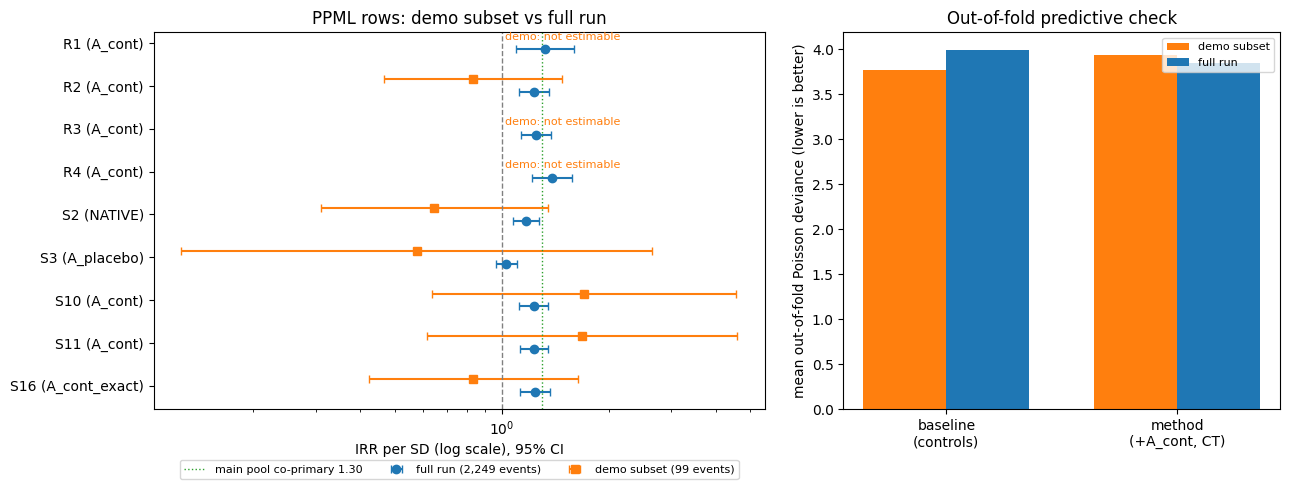

In [18]:
plot_keys = [k for k in ["R1", "R2", "R3", "R4", "S2", "S3", "S10", "S11", "S16"] if k in full_rows]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.4, 1]})
ax = axes[0]
demo_labelled = False
for i, k in enumerate(plot_keys):
    fr = full_rows[k]
    ax.errorbar(fr["irr_sd"], i + 0.15, xerr=[[fr["irr_sd"] - fr["ci"][0]], [fr["ci"][1] - fr["irr_sd"]]],
                fmt="o", color="tab:blue", capsize=3, label="full run (2,249 events)" if i == 0 else None)
    row = R.get(k, {}).get("row")
    d = row.get(fr["var"]) if row else None
    if d and np.isfinite(d["irr_sd"]):
        lo, hi = d["ci_irr_sd"]
        ax.errorbar(d["irr_sd"], i - 0.15, xerr=[[d["irr_sd"] - lo], [hi - d["irr_sd"]]], fmt="s", color="tab:orange",
                    capsize=3, label=None if demo_labelled else f"demo subset ({len(om)} events)")
        demo_labelled = True
    else:
        ax.text(1.02, i - 0.15, "demo: not estimable", va="center", fontsize=8, color="tab:orange")
ax.axvline(1.0, color="grey", lw=1, ls="--")
ax.axvline(MAIN_COPRIMARY["irr_sd"], color="tab:green", lw=1, ls=":", label="main pool co-primary 1.30")
ax.set_xscale("log")
ax.set_yticks(range(len(plot_keys)))
ax.set_yticklabels([f"{k} ({full_rows[k]['var']})" for k in plot_keys])
ax.invert_yaxis()
ax.set_xlabel("IRR per SD (log scale), 95% CI")
ax.set_title("PPML rows: demo subset vs full run")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)

ax = axes[1]
full_oos = data["metadata"]["oos"]
labels = ["baseline\n(controls)", "method\n(+A_cont, CT)"]
x = np.arange(2)
ax.bar(x - 0.18, [oos["mean_deviance_baseline"], oos["mean_deviance_method"]], 0.36, label="demo subset", color="tab:orange")
ax.bar(x + 0.18, [full_oos["mean_deviance_baseline"], full_oos["mean_deviance_method"]], 0.36, label="full run", color="tab:blue")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("mean out-of-fold Poisson deviance (lower is better)")
ax.set_title("Out-of-fold predictive check")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()